# Stocks

A Python package to download company financial data from yahoo.

# Load Packages

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from datetime import date
import yfinance as yf

# Company Stock Price

In [2]:
# Choose ticker and dates
my_ticker = "DIS"
start_date = "2000-01-01"
end_date = str(date.today())

# Download stock prices
df = yf.download(my_ticker, start=start_date, end=end_date)
print("\n",my_ticker,"stock data")
print("\n","data shape",df.shape)
display(df.head())
display(df.tail())

[*********************100%***********************]  1 of 1 completed

 DIS stock data

 data shape (6192, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,28.855125,29.533344,28.361876,29.471687,22.934361,8402230
2000-01-04,29.594999,31.444689,29.594999,31.198063,24.277790,16051191
2000-01-05,31.198063,32.677814,31.198063,32.492844,25.285368,19823822
2000-01-06,32.492844,32.677814,31.198063,31.198063,24.277790,7903193
2000-01-07,31.198063,31.691313,30.396530,30.704813,23.893953,6773543


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-08-07,88.000000,89.239998,85.750000,85.959999,85.959999,30581900
2024-08-08,85.150002,86.330002,83.910004,85.959999,85.959999,21890500
2024-08-09,86.129997,86.250000,84.709999,86.209999,86.209999,16008400
2024-08-12,85.860001,86.379997,85.480003,85.949997,85.949997,11754600
2024-08-13,86.459999,86.459999,85.309998,85.599998,85.599998,14602500


In [3]:
max_price = str(round(max(df["High"]),2))
max_price_date = str(df[df["High"]==max(df["High"])].index[0]).split(" ")[0]
print("The max price of {} for {} occurred on {}.".format(max_price,my_ticker,max_price_date))

The max price of 203.02 for DIS occurred on 2021-03-08.


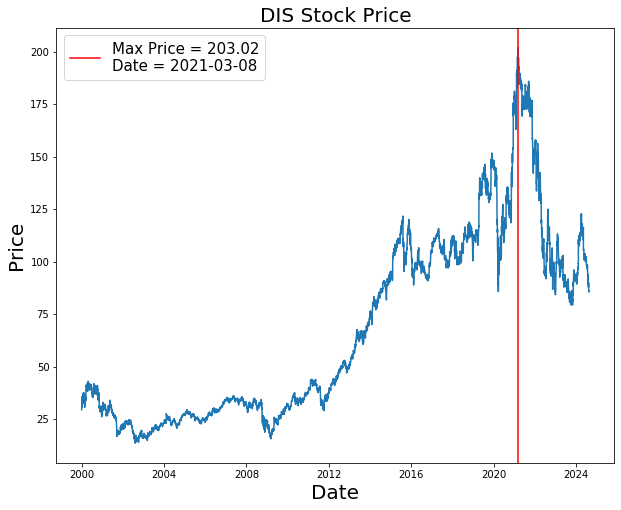

In [4]:
fig = plt.figure(figsize=(10,8))
plt.plot(df["Close"])
plt.title(my_ticker+" Stock Price", fontsize=20)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Price", fontsize=20)
plt.axvline(x=df[df["High"]==max(df["High"])].index[0], color="red", label="Max Price = "+max_price+"\nDate = "+max_price_date)
plt.legend(loc="upper left", fontsize=15)
plt.show()

# Additional Financial Data

In [5]:
my_obj = yf.Ticker(my_ticker)

## Company Information

In [6]:
my_obj.info

{'regularMarketPrice': None, 'preMarketPrice': None, 'logo_url': ''}

## Historical Market Data

In [7]:
my_obj.history(period="max")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1962-01-02,0.057941,0.059886,0.057941,0.057941,841958,0.0,0.0
1962-01-03,0.057941,0.058914,0.057941,0.058719,801865,0.0,0.0
1962-01-04,0.058719,0.058914,0.058331,0.058719,962238,0.0,0.0
1962-01-05,0.058719,0.059108,0.058525,0.058914,962238,0.0,0.0
1962-01-08,0.058914,0.059691,0.057553,0.058719,1282984,0.0,0.0
...,...,...,...,...,...,...,...
2024-08-08,85.150002,86.330002,83.910004,85.959999,21890500,0.0,0.0
2024-08-09,86.129997,86.250000,84.709999,86.209999,16008400,0.0,0.0
2024-08-12,85.860001,86.379997,85.480003,85.949997,11754600,0.0,0.0


## Dividends and Stock Splits

In [8]:
my_obj.actions

,Dividends,Stock Splits
Date,,
1962-03-13,0.000249,0.00
1962-06-12,0.000249,0.00
1962-09-11,0.000249,0.00
1962-12-18,0.000257,1.03
1963-03-12,0.000257,0.00
...,...,...
2018-12-07,0.880000,0.00
2019-07-05,0.880000,0.00
2019-12-13,0.880000,0.00


## Dividends

In [9]:
my_obj.dividends

Date
1962-03-13    0.000249
1962-06-12    0.000249
1962-09-11    0.000249
1962-12-18    0.000257
1963-03-12    0.000257
                ...   
2018-12-07    0.880000
2019-07-05    0.880000
2019-12-13    0.880000
2023-12-08    0.300000
2024-07-08    0.450000
Name: Dividends, Length: 126, dtype: float64

## Splits

In [10]:
my_obj.splits

Date
1962-12-18    1.030000
1967-11-16    2.000000
1971-03-01    2.000000
1973-01-16    2.000000
1986-03-06    4.000000
1992-05-18    4.000000
1998-07-10    3.000000
2007-06-13    1.013685
Name: Stock Splits, dtype: float64

## Yearly Financials

In [11]:
my_obj.financials

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Quarterly Financials

In [12]:
my_obj.quarterly_financials

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Major Holders

In [13]:
my_obj.major_holders

,Breakdown,Unnamed: 1
0,0.06%,% of Shares Held by All Insider
1,70.84%,% of Shares Held by Institutions
2,70.88%,% of Float Held by Institutions
3,3889,Number of Institutions Holding Shares


## Institutional Holders

In [14]:
my_obj.institutional_holders

,Holder,Shares,Date Reported,% Out,Value
0,Vanguard Group Inc,154.81M,2024-06-30,0.0854,13331106483
1,Blackrock Inc.,122.28M,2024-06-30,0.0674,10529674247
2,State Street Corporation,76.04M,2024-03-31,0.0419,6547721694
3,Morgan Stanley,47.83M,2024-03-31,0.0264,4118336758
4,"Geode Capital Management, LLC",36.28M,2024-06-30,0.0200,3124005206
5,"Trian Fund Management, LP",32.34M,2024-03-31,0.0178,2784612799
6,"FMR, LLC",31.65M,2024-06-30,0.0175,2725491654
7,State Farm Mutual Automobile Insurance Co,30.76M,2024-06-30,0.0170,2649061623
8,Norges Bank Investment Management,21.47M,2023-12-31,0.0118,1848897100
9,Northern Trust Corporation,21.49M,2024-03-31,0.0118,1850540595


## Yearly Balance Sheet

In [15]:
my_obj.balance_sheet

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Quarterly Balance Sheet

In [16]:
my_obj.quarterly_balance_sheet

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Yearly Cashflow

In [17]:
my_obj.cashflow

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Quarterly Cashflow

In [18]:
my_obj.quarterly_cashflow

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Yearly Earnings

In [19]:
my_obj.earnings

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Quarterly Earnings

In [20]:
my_obj.quarterly_earnings

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


## Sustainability

In [21]:
my_obj.sustainability

## Analyst Recommendations

In [22]:
my_obj.recommendations

## Calendar

In [23]:
my_obj.calendar

## Option Expiration Dates

In [24]:
my_obj.options

()

## Option Chain for Specific Expiration

In [25]:
# my_obj.option_chain('2025-01-01')

## News

In [26]:
my_obj.news

[{'uuid': '31420df8-67b3-359a-99ac-f5ee08959821',
  'title': 'Rogers Communication (RCI), SenseNet Tie Up for New Technology',
  'publisher': 'Zacks',
  'link': 'https://finance.yahoo.com/news/rogers-communication-rci-sensenet-tie-144000272.html',
  'providerPublishTime': 1723646400,
  'type': 'STORY',
  'thumbnail': {'resolutions': [{'url': 'https://s.yimg.com/uu/api/res/1.2/Dq1vlMLW3T8P7HdViFj_kQ--~B/aD00MTM7dz02MjA7YXBwaWQ9eXRhY2h5b24-/https://media.zenfs.com/en/zacks.com/3eef6fea1055ab55d5c65f84ddc8db0f',
     'width': 620,
     'height': 413,
     'tag': 'original'},
    {'url': 'https://s.yimg.com/uu/api/res/1.2/Pc4Zin3jt5QNhuGBiiF2KQ--~B/Zmk9ZmlsbDtoPTE0MDtweW9mZj0wO3c9MTQwO2FwcGlkPXl0YWNoeW9u/https://media.zenfs.com/en/zacks.com/3eef6fea1055ab55d5c65f84ddc8db0f',
     'width': 140,
     'height': 140,
     'tag': '140x140'}]},
  'relatedTickers': ['RCI', 'DIS']},
 {'uuid': 'b7227268-325d-3d3d-9b5a-663a4ea2400c',
  'title': '4 Broadcast Radio & TV Stocks to Watch From a Challeng